## Analyse des stems SnowBall vs lemmes SpaCy
Dans ce notebook nous analysons l'impact du stemming et de la lemmatisation pour les comparer.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
OUTPUTS  = Path("../exercices-td/outputs-td3")


In [13]:
snow = pd.read_csv(OUTPUTS / "stems_snow.tsv", sep = "\t")
space = pd.read_csv(OUTPUTS / "stems_spacy.tsv", sep = "\t")
token_freq = snow.groupby("token").size().to_frame(name="freq").reset_index()
snow_freq = snow.groupby("lemma").size().to_frame(name="freq").reset_index()
space_freq = space.groupby("lemma").size().to_frame(name="freq").reset_index()

snow_unique = snow.drop_duplicates("token")

space_unique = space.drop_duplicates("token")

In [14]:
snow.describe()

,token,lemma
count,90451,90449
unique,14737,9487
top,nous,développ
freq,458,501


In [15]:
space.describe()

,token,lemma
count,90451,90451
unique,14737,11738
top,nous,son
freq,458,723


In [16]:
def plot_lemma_pareto(freq_tables, lemma_col='lemma', freq_col='freq'):
    """
    Builds a Pareto plot comparing cumulative corpus coverage across multiple tables.
    
    Args:
        freq_tables (dict): A dictionary where keys are names (e.g., 'Snow') 
                           and values are DataFrames containing frequency data.
    """
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    for name, df in freq_tables.items():
        df_sorted = df.sort_values(freq_col, ascending=False).copy()
        df_sorted['cum_counts'] = df_sorted[freq_col].cumsum()
        df_sorted['corpus_coverage'] = df_sorted['cum_counts'] / df_sorted[freq_col].sum()
        df_sorted['vocab_percent'] = np.arange(1, len(df_sorted) + 1) / len(df_sorted)
        sns.lineplot(data=df_sorted, x='vocab_percent', y='corpus_coverage', label=name, lw=2)

    # Aesthetics
    plt.axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80% Coverage')
    plt.title("Pareto Curve: Cumulative Corpus Coverage by Vocabulary", fontsize=14)
    plt.xlabel("Proportion of Unique Vocabulary (Lemmas)", fontsize=12)
    plt.ylabel("Proportion of Total Text (Corpus)", fontsize=12)
    plt.xlim(0, 1.0)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

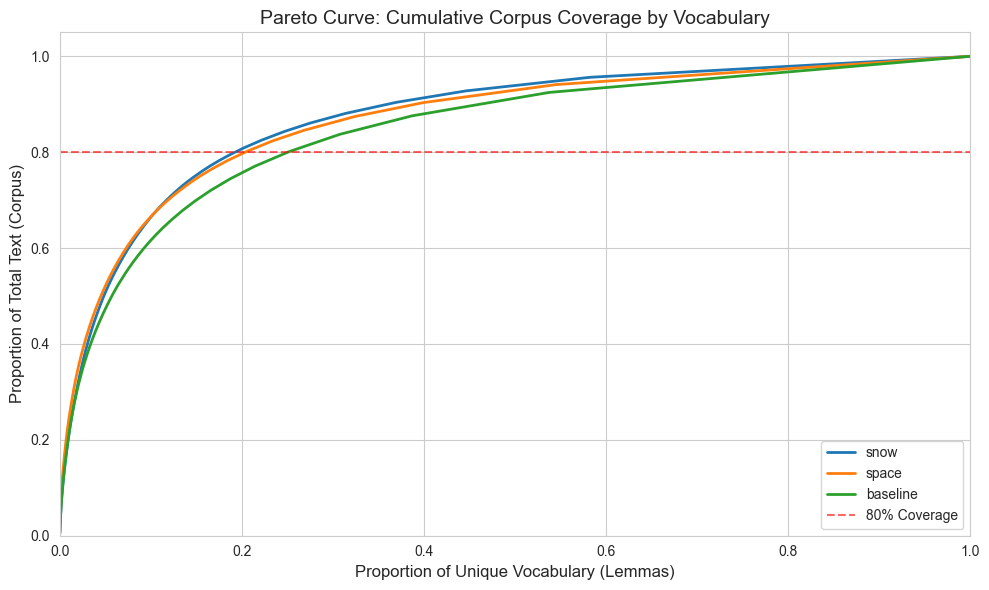

In [17]:
plot_lemma_pareto({"snow" : snow_freq, "space" : space_freq, "baseline" : token_freq })